In [2]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())

Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [3]:
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])

Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

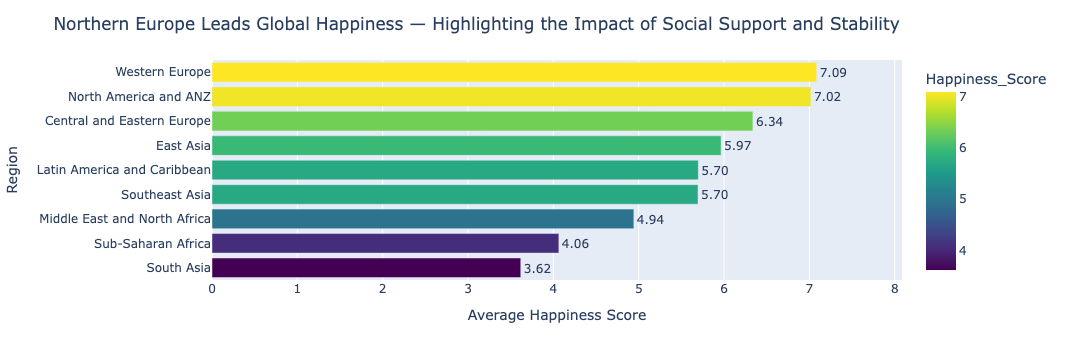

In [6]:
# Task 1: Regional comparison bar chart
# -------------------------------------

# Step 1: Compute average happiness score by region
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score',ascending=False))

# Step 2: Build horizontal bar chart
fig = px.bar(
    region_avg,
    x='Happiness_Score',
    y='Region',
    orientation='h',
    text='Happiness_Score',
    color='Happiness_Score',  # adds visual gradient
    color_continuous_scale='Viridis'
)

# Step 3: Improve design
fig.update_layout(
title="Northern Europe Leads Global Happiness — Highlighting the Impact of Social Support and Stability",
    xaxis_title="Average Happiness Score",
    yaxis_title="Region",
    xaxis=dict(range=[0, region_avg['Happiness_Score'].max() + 1])  # zero baseline
)

# Make labels cleaner
fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

# Reverse y-axis so highest appears at the top
fig.update_layout(yaxis=dict(autorange="reversed"))

fig.show()




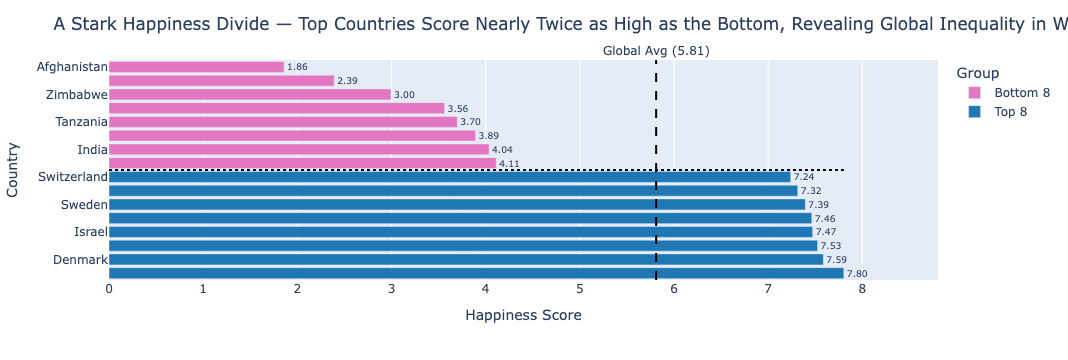

In [9]:
import plotly.express as px
import plotly.graph_objects as go

# Step 2: Build chart
fig = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    orientation='h',
    color='Group',
    text='Happiness_Score',
    color_discrete_map={
        'Top 8': '#1f77b4',      # blue for happiest
        'Bottom 8': '#e377c2'    # pink for least happy
    }
)

# Clean labels
fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside'
)

# Add vertical line for global average (stretch goal)
fig.add_vline(
    x=global_avg,
    line_dash="dash",
    line_color="black",
    annotation_text=f"Global Avg ({global_avg:.2f})",
    annotation_position="top"
)

# Add visual separator between bottom and top groups
fig.add_shape(
    type="line",
    x0=0,
    x1=combined['Happiness_Score'].max(),
    y0=7.5,  # between 8th and 9th bar
    y1=7.5,
    line=dict(color="black", dash="dot")
)

# Insight-driven title + layout tweaks
fig.update_layout(
    title="A Stark Happiness Divide — Top Countries Score Nearly Twice as High as the Bottom, Revealing Global Inequality in Well-being",
    xaxis_title="Happiness Score",
    yaxis_title="Country",
    xaxis=dict(range=[0, combined['Happiness_Score'].max() + 1]),
    yaxis=dict(autorange="reversed")
)

fig.show()

Identified Columns: GDP -> 'GDP', Freedom -> 'Freedom'
                          GDP   Freedom
Region                                 
East Asia           10.312000  0.754000
South Asia           7.152250  0.546250
Sub-Saharan Africa   7.082000  0.599429
Western Europe      10.963533  0.896067


Matplotlib is building the font cache; this may take a moment.


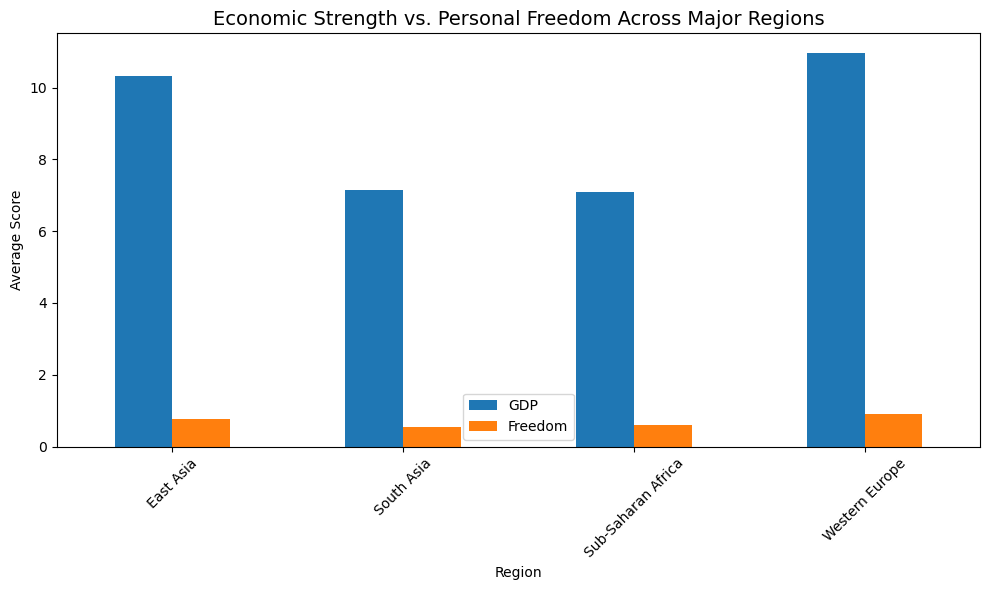

In [11]:
# Task 3: Stretch goal — grouped bar chart
# ----------------------------------------

# Step 1: Automatically find columns containing keywords
# This finds any column with 'GDP' or 'Freedom' in the name (case-insensitive)
gdp_col = [c for c in df.columns if 'gdp' in c.lower()][0]
freedom_col = [c for c in df.columns if 'freedom' in c.lower()][0]

target_regions = ['Western Europe', 'Latin America', 'East Asia', 'Sub-Saharan Africa', 'South Asia']
columns_to_plot = [gdp_col, freedom_col]

# Filter and group
stretch_data = (df[df['Region'].isin(target_regions)]
                .groupby('Region')[columns_to_plot]
                .mean())

print(f"Identified Columns: GDP -> '{gdp_col}', Freedom -> '{freedom_col}'")
print(stretch_data)

# Step 2: Build your chart
import matplotlib.pyplot as plt

# Plotting
stretch_data.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])

plt.title('Economic Strength vs. Personal Freedom Across Major Regions', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.legend(['GDP', 'Freedom'])

plt.tight_layout()
plt.show()